# Face Anonymization from 5 Given Landmarks (cedalion-only)

Pure-geometric face-removal pipeline for Einstar scans. Takes the 5 standard
anatomical landmarks (Nz, Iz, Cz, Lpa, Rpa) as input and deletes the facial
region without any ML / face-detection dependency.

**Pipeline:**
1. Load scan
2. Pick 5 landmarks interactively via `cedalion.plots.plot_surface(pick_landmarks=True)`
3. Wrap into a `LabeledPointCloud`
4. Normalize axes (X=up, Y=anterior, Z=left) and isolate head
5. Build face-region mask purely from the 5 landmarks
6. Visualize the mask
7. Delete masked vertices (no smoothing)
8. Validate result

This is the cedalion-only alternative to notebook 47's MediaPipe pipeline and
matches the exposé contract: NAS/LPA/RPA assumed given, no DL face detection.

In [33]:
import logging

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import xarray as xr

import cedalion
import cedalion.dataclasses as cdc
import cedalion.io
import cedalion.plots
from cedalion.geometry.photogrammetry.anonymization import (
    normalize_axes,
    isolate_head,
    align_axes_from_landmarks,
    detect_cap_boundary,
    face_mask_from_landmarks,
    delete_masked_vertices,
    save_anonymized_scan,
    validate_anonymization,
)
from cedalion.vtktutils import trimesh_to_vtk_polydata
from cedalion.dataclasses import VTKSurface

logging.getLogger('cedalion').setLevel(logging.WARNING)
pv.set_jupyter_backend('server')

# === CONFIG ===
SUBJECT_NUMBER = 17
SCANS_FOLDER = '/home/ma7/BA/PG_Subjects'

# True: run the picker. False: use cached landmarks (fill after first pick).
INTERACTIVE = True

# Mask tunables (mm)
LANDMARK_KEEP_RADIUS = 8.0      # preserve a small sphere around each landmark
EAR_DELETE_RADIUS_MM = 40.0     # radius of the delete sphere around Lpa / Rpa

# Cap boundary detection tunables
CAP_BAND_WIDTH_MM = 15.0
CAP_BIN_SIZE_MM = 2.0
CAP_FOOT_GRAD_THRESHOLD = 0.2

## 1. Load the Einstar scan

In [34]:
path = f'{SCANS_FOLDER}/Subject{SUBJECT_NUMBER}/Subject{SUBJECT_NUMBER}.obj'
surface = cedalion.io.read_einstar_obj(path)
print(f'Loaded: {surface.nvertices:,} vertices, {surface.nfaces:,} faces')

# In trimesh 4.6 the texture image lives on visual.material.image, not
# visual.image. Verify it's there; if missing, fall back to the sibling JPG.
import os
import trimesh as _tm
from PIL import Image as _PILImage

def _visual_image(visual):
    img = getattr(visual, 'image', None)
    if img is None:
        mat = getattr(visual, 'material', None)
        img = getattr(mat, 'image', None) if mat is not None else None
    return img

_img = _visual_image(surface.mesh.visual)
if _img is None:
    _jpg = path.replace('.obj', '.jpg')
    _uv = getattr(surface.mesh.visual, 'uv', None)
    assert os.path.exists(_jpg) and _uv is not None, (
        f'no texture: jpg_exists={os.path.exists(_jpg)}, has_uv={_uv is not None}'
    )
    surface.mesh.visual = _tm.visual.TextureVisuals(
        uv=_uv, image=_PILImage.open(_jpg).convert('RGBA'),
    )
    _img = _visual_image(surface.mesh.visual)
    assert _img is not None, 'attach failed'
    print(f'Attached texture from JPG: {_img.size}')
else:
    print(f'Texture already attached: {_img.size}')

Loaded: 1,284,667 vertices, 2,223,716 faces
Texture already attached: (4016, 3776)


## 2. Pick the 5 landmarks interactively

Uses cedalion's built-in picker (`cedalion.plots.plot_surface(..., pick_landmarks=True)`,
authored by Mariia Iudina, upstream cedalion). Right-click on the mesh to place a
sphere; click again on the sphere to cycle its label through
`Nz -> Iz -> Cz -> Lpa -> Rpa`, or cycle past `Rpa` back to `Nz` to remove it.

Close the window when all 5 are placed with correct labels.

In [35]:
if INTERACTIVE:
    pvplt = pv.Plotter()
    get_landmarks = cedalion.plots.plot_surface(
        pvplt, surface, opacity=1.0, pick_landmarks=True
    )
    pvplt.show()

Widget(value='<iframe src="http://localhost:45595/index.html?ui=P_0x7fdaa44a0610_10&reconnect=auto" class="pyv…

## 3. Retrieve picked points and wrap into a `LabeledPointCloud`

Follows the pattern from `41_photogrammetric_optode_coregistration.ipynb` cells 26-28.

In [36]:
if INTERACTIVE:
    landmark_coordinates, landmark_labels = get_landmarks()
    landmark_coordinates = np.asarray(landmark_coordinates)
else:
    # Cached fallback: paste coordinates from a previous interactive run here.
    landmark_labels = ['Nz', 'Iz', 'Cz', 'Lpa', 'Rpa']
    landmark_coordinates = np.asarray([
        [0.0, 0.0, 0.0],   # Nz  -- replace
        [0.0, 0.0, 0.0],   # Iz  -- replace
        [0.0, 0.0, 0.0],   # Cz  -- replace
        [0.0, 0.0, 0.0],   # Lpa -- replace
        [0.0, 0.0, 0.0],   # Rpa -- replace
    ])

assert len(set(landmark_labels)) == 5, 'Need exactly 5 distinct landmarks'
assert set(landmark_labels) == {'Nz', 'Iz', 'Cz', 'Lpa', 'Rpa'}, (
    f'Unexpected labels: {landmark_labels}'
)

landmarks = xr.DataArray(
    np.vstack(landmark_coordinates),
    dims=['label', 'digitized'],
    coords={
        'label': ('label', list(landmark_labels)),
        'type': ('label', [cdc.PointType.LANDMARK] * 5),
        'group': ('label', ['L'] * 5),
    },
).pint.quantify('mm')

display(landmarks)

Magnitude,[[182.78403277337682 119.00435797327856 431.95041939265843] [53.21676427926042 219.20228469014984 461.11116232532544] [69.61090726159273 81.05491958613379 564.6012768794676] [71.16199191638447 -12.73670574349066 478.04621170118133] [-9.011772572255389 59.78899074619693 423.63767741978666]]
Units,millimeter


## 4. Normalize axes and isolate head

`normalize_axes` rotates the mesh around its X-axis so Y points anterior (toward
the face) and Z points left. We apply the same rotation to the 5 landmarks so
they stay consistent with the mesh. After this, the canonical frame is:
X=up, Y=anterior, Z=left.

In [37]:
# Step 1: Mediapipe-compatible X-rotation so Y points anterior.
lm_raw = landmarks.pint.dequantify().values
idx = {lbl: i for i, lbl in enumerate(landmarks['label'].values)}
Nz_raw = lm_raw[idx['Nz']]

surface_n, Nz_n, R = normalize_axes(surface, Nz_raw)
landmarks_n = landmarks.pint.dequantify().copy(data=lm_raw @ R.T).pint.quantify()

# Head isolation (strips shoulders/background).
surface_n, _ = isolate_head(surface_n, Nz_n)
print(f'After isolate_head: {surface_n.nvertices:,} vertices')

# Step 2: Full 5-landmark alignment to canonical frame (X=up, Y=ant, Z=left).
surface_h, landmarks_n, R2 = align_axes_from_landmarks(surface_n, landmarks_n)
lm_n = landmarks_n.pint.dequantify().values
Nz, Iz, Cz, Lpa, Rpa = (lm_n[idx[lbl]] for lbl in ['Nz', 'Iz', 'Cz', 'Lpa', 'Rpa'])
ear_mid = 0.5 * (Lpa + Rpa)

print('\nAligned landmarks:')
verts = np.asarray(surface_h.mesh.vertices)
for lbl, pos in zip(['Nz', 'Iz', 'Cz', 'Lpa', 'Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    d = np.linalg.norm(verts - pos, axis=1).min()
    print(f'  {lbl}: {pos}  (on mesh: {d:.2f} mm)')

After isolate_head: 678,081 vertices

Aligned landmarks:
  Nz: [-184.49706053  -15.58120797 -446.62343636]  (on mesh: 0.66 mm)
  Iz: [ -83.08828247 -225.51510363 -453.59061387]  (on mesh: 0.11 mm)
  Cz: [ -18.54212354  -74.10802095 -477.82569578]  (on mesh: 0.66 mm)
  Lpa: [-184.49706053 -109.48535945 -370.2682918 ]  (on mesh: 0.55 mm)
  Rpa: [-184.49706053 -109.48535945 -533.0703246 ]  (on mesh: 0.28 mm)


## 5. Build the face-region mask from the 5 landmarks

Two parts:

1. **Cap boundary detection:** Scan upward from Nz along the midline. In each
   height bin, find the most anterior vertex (max Y). The forehead shows a smooth
   Y decrease; the cap edge shows a sudden Y drop. The X value where that drop
   first exceeds `CAP_GRADIENT_THRESHOLD` is `cap_x`.

2. **Mask rules** (in the aligned frame X=up, Y=anterior, Z=left):
   - `X < cap_x` (below the cap boundary -- covers face + forehead)
   - `Y > ear_mid_y` (anterior to the coronal ear plane)
   - `|Z - mid_z| < half_width` (within lateral width, ears excluded)

Cap boundary detected at X = -153.5 mm  (Nz_x=-184.5, Cz_x=-18.5)


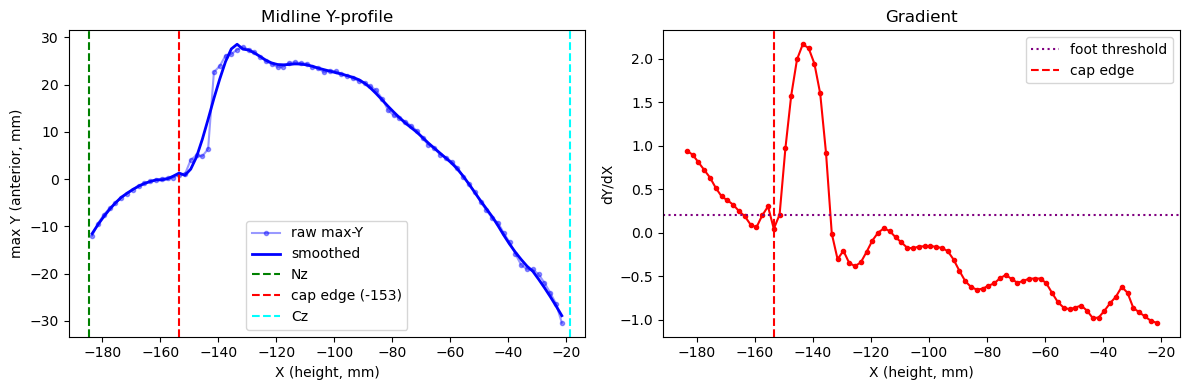

Nasion strip preserved: 1,569 vertices
Mask: 110,763 / 678,081 vertices (16.3%)
Per-rule counts: {'below_cap': 293056, 'face_region': 98815, 'ear_region': 33835, 'all': 113710}


In [38]:
# 1. Detect cap boundary from midline Y-profile.
verts = np.asarray(surface_h.mesh.vertices)
mid_z = 0.5 * (Lpa[2] + Rpa[2])

cap_x, profile_x, profile_y, profile_y_s = detect_cap_boundary(
    verts, Nz, Cz, ear_mid, mid_z,
    band_width=CAP_BAND_WIDTH_MM,
    bin_size=CAP_BIN_SIZE_MM,
    foot_grad_threshold=CAP_FOOT_GRAD_THRESHOLD,
)
print(f'Cap boundary detected at X = {cap_x:.1f} mm  '
      f'(Nz_x={Nz[0]:.1f}, Cz_x={Cz[0]:.1f})')

# Debug plot: Y-profile along midline (raw + smoothed) + gradient.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(profile_x, profile_y, 'b.-', alpha=0.4, label='raw max-Y')
ax1.plot(profile_x, profile_y_s, 'b-', lw=2, label='smoothed')
ax1.axvline(Nz[0], color='green', ls='--', label='Nz')
ax1.axvline(cap_x, color='red', ls='--', label=f'cap edge ({cap_x:.0f})')
ax1.axvline(Cz[0], color='cyan', ls='--', label='Cz')
ax1.set_xlabel('X (height, mm)')
ax1.set_ylabel('max Y (anterior, mm)')
ax1.set_title('Midline Y-profile')
ax1.legend()

grad = np.gradient(profile_y_s, profile_x)
ax2.plot(profile_x, grad, 'r.-')
ax2.axhline(CAP_FOOT_GRAD_THRESHOLD, color='purple', ls=':', label='foot threshold')
ax2.axvline(cap_x, color='red', ls='--', label='cap edge')
ax2.set_xlabel('X (height, mm)')
ax2.set_ylabel('dY/dX')
ax2.set_title('Gradient')
ax2.legend()
plt.tight_layout()
plt.show()

# 2. Build face+ear mask from landmarks.
mask, mask_info = face_mask_from_landmarks(
    verts, Nz, Iz, Cz, Lpa, Rpa,
    cap_x=cap_x,
    ear_delete_radius=EAR_DELETE_RADIUS_MM,
)

# 3. Preserve small spheres around each landmark point.
for lm in (Nz, Iz, Cz, Lpa, Rpa):
    near = np.linalg.norm(verts - lm, axis=1) < LANDMARK_KEEP_RADIUS
    mask[near] = False

# 4. Preserve a midline Nz strip upward to the cap boundary (for coregistration).
nasion_strip = (
    (verts[:, 0] >= Nz[0]) &
    (verts[:, 0] < cap_x) &
    (np.abs(verts[:, 2] - Nz[2]) < LANDMARK_KEEP_RADIUS) &
    (verts[:, 1] > ear_mid[1])
)
mask[nasion_strip] = False

print(f'Nasion strip preserved: {int(nasion_strip.sum()):,} vertices')
print(f'Mask: {mask.sum():,} / {len(mask):,} vertices '
      f'({100*mask.sum()/len(mask):.1f}%)')
print(f'Per-rule counts: {mask_info["counts"]}')

## 6. Visualize the anonymization mask

Red = will be deleted, white = kept. The 5 landmark spheres are overlaid for
orientation. This is the primary deliverable — if the red region hugs the face
without leaking onto ears / top-of-head / neck, the geometric rules are working.

In [39]:
lm_colors = {'Nz': 'lime', 'Iz': 'magenta', 'Cz': 'cyan', 'Lpa': 'orange', 'Rpa': 'blue'}

pvplt = pv.Plotter()

vtk_surface = VTKSurface.from_trimeshsurface(surface_h)
pv_mesh = pv.wrap(vtk_surface.mesh)
pv_mesh['mask'] = mask.astype(float)
pvplt.add_mesh(
    pv_mesh, scalars='mask', cmap=['white', 'red'], clim=[0, 1],
    show_scalar_bar=False, opacity=1.0, smooth_shading=True,
)

for lbl, pos in zip(landmarks_n['label'].values, lm_n):
    c = lm_colors.get(lbl, 'yellow')
    pvplt.add_mesh(pv.Sphere(radius=4, center=pos), color=c)
    pvplt.add_point_labels(
        [pos], [lbl], font_size=16, text_color=c, shape=None, always_visible=True,
    )

pvplt.add_text(
    f'S{SUBJECT_NUMBER} | mask: {mask.sum():,} / {len(mask):,} verts '
    f'({100*mask.sum()/len(mask):.1f}%)',
    position='upper_left', font_size=12,
)
pvplt.show()

Widget(value='<iframe src="http://localhost:45595/index.html?ui=P_0x7fd8872f52d0_11&reconnect=auto" class="pyv…

## 7. Anonymize by deleting masked vertices

Drops every triangle that has any masked vertex, then strips unreferenced
vertices. Pure trimesh, no smoothing.

In [40]:
surface_anon = delete_masked_vertices(surface_h, mask)
n_removed = surface_h.nvertices - surface_anon.nvertices
print(f'Original:    {surface_h.nvertices:,} verts, {surface_h.nfaces:,} faces')
print(f'Anonymized:  {surface_anon.nvertices:,} verts, {surface_anon.nfaces:,} faces')
print(f'Removed:     {n_removed:,} verts')

Original:    678,081 verts, 1,171,705 faces
Anonymized:  567,180 verts, 973,360 faces
Removed:     110,901 verts


## 8. Before / after

In [41]:
orig_vtk = trimesh_to_vtk_polydata(surface_h.mesh)
anon_vtk = trimesh_to_vtk_polydata(surface_anon.mesh)

pvplt = pv.Plotter(shape=(1, 2))

pvplt.subplot(0, 0)
pvplt.add_mesh(pv.wrap(orig_vtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(landmarks_n['label'].values, lm_n):
    pvplt.add_mesh(pv.Sphere(radius=4, center=pos),
                   color=lm_colors.get(lbl, 'yellow'))
pvplt.add_text(f'S{SUBJECT_NUMBER} Original', position='upper_left', font_size=14)

pvplt.subplot(0, 1)
pvplt.add_mesh(pv.wrap(anon_vtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(landmarks_n['label'].values, lm_n):
    pvplt.add_mesh(pv.Sphere(radius=4, center=pos),
                   color=lm_colors.get(lbl, 'yellow'))
pvplt.add_text(
    f'S{SUBJECT_NUMBER} Anonymized (-{n_removed:,} verts)',
    position='upper_left', font_size=14,
)

pvplt.link_views()
pvplt.show()

Widget(value='<iframe src="http://localhost:45595/index.html?ui=P_0x7fd898d73150_12&reconnect=auto" class="pyv…

## 9. Validate

Sanity-check the result: vertex count dropped, no degenerate faces, landmarks
still reachable on the anonymized surface.

In [42]:
result = validate_anonymization(
    original_surface=surface_h,
    anonymized_surface=surface_anon,
    facial_mask=mask,
    protected_points=landmarks_n,
    tolerance=5.0 * cedalion.units.mm,
)
print(result)

ValidationResult(face_removed=True, mesh_valid=True, expected_vertices_removed=110763, actual_vertices_removed=110901, protected_points_intact=True, protected_point_max_deviation=0.6601578237143165, face_coverage_pct=16.33477416414853, passed=True, summary='PASSED — 110,901 vertices removed (16.3%), mesh valid, protected points within 5.0mm')


## 10. Save the anonymized scan

Writes only the `.obj` geometry. The texture is stripped so the original face
pixels from the Einstar `.jpg` are not written to disk. No `.mtl`, no `.jpg`.

In [43]:
out = f'{SCANS_FOLDER}/Subject{SUBJECT_NUMBER}/Subject{SUBJECT_NUMBER}_anon.obj'
written = save_anonymized_scan(surface_anon, out, with_color=True)
print('Wrote:')
for p in written:
    print(f'  {p}')


with_color=True requested but mesh has no usable texture; falling back to uniform grey vertex colors.


Wrote:
  /home/ma7/BA/PG_Subjects/Subject17/Subject17_anon.obj


## 11. Validation via optode coregistration

Thesis-reporting block. Runs the sticker-detection + scalp-projection half of
notebook 41 on both the pre- and post-anonymization meshes and compares the
resulting coordinates.

Rationale: the anonymization mask only touches the face region. Optode
stickers sit on the cap, well outside the mask. So sticker centers and
scalp-projected coordinates should be invariant under anonymization. Any
measurable delta localizes boundary leakage of the mask.

No `.snirf` montage exists for Subject16-22, so we stop at scalp coordinates
(no ICP label assignment). See
`41_photogrammetric_optode_coregistration.ipynb` for the full pipeline.

[[ -85.14637603  -45.3311207  -550.53511232]
 [ -54.06411602 -125.21770066 -556.68425171]
 [ -85.56239656  -45.2187465  -550.48027075]
 ...
 [-251.74365272 -216.53318818 -500.27608009]
 [-175.64948551  -29.62507408 -410.93197906]
 [-127.42518785 -235.54048938 -407.91215556]]
[[ -55.00372802 -119.87129556 -557.60451328]
 [ -54.04357226 -123.86408342 -556.79642487]
 [ -18.73912569  -97.45110731 -526.52592796]
 ...
 [ -89.21370455   20.04153786 -466.36143248]
 [ -88.92333199   19.75613378 -466.48283384]
 [ -47.2857347   -13.5402963  -484.98917796]]
O (0.11, 0.21, 0.7, 1.0)
[0.4250353  1.35472219 1.7145254  0.39138499 1.29862752 0.62320719
 0.38994548 0.61920156 0.78096456 0.49167592 1.33193309 0.74436605
 1.48520167 1.26870412 0.9219634  1.02609914 0.93732249 0.66719798
 0.08219981 1.76435313 0.45591146]
3.728244425455729
surface.crs digitized
Stickers detected on original: 21


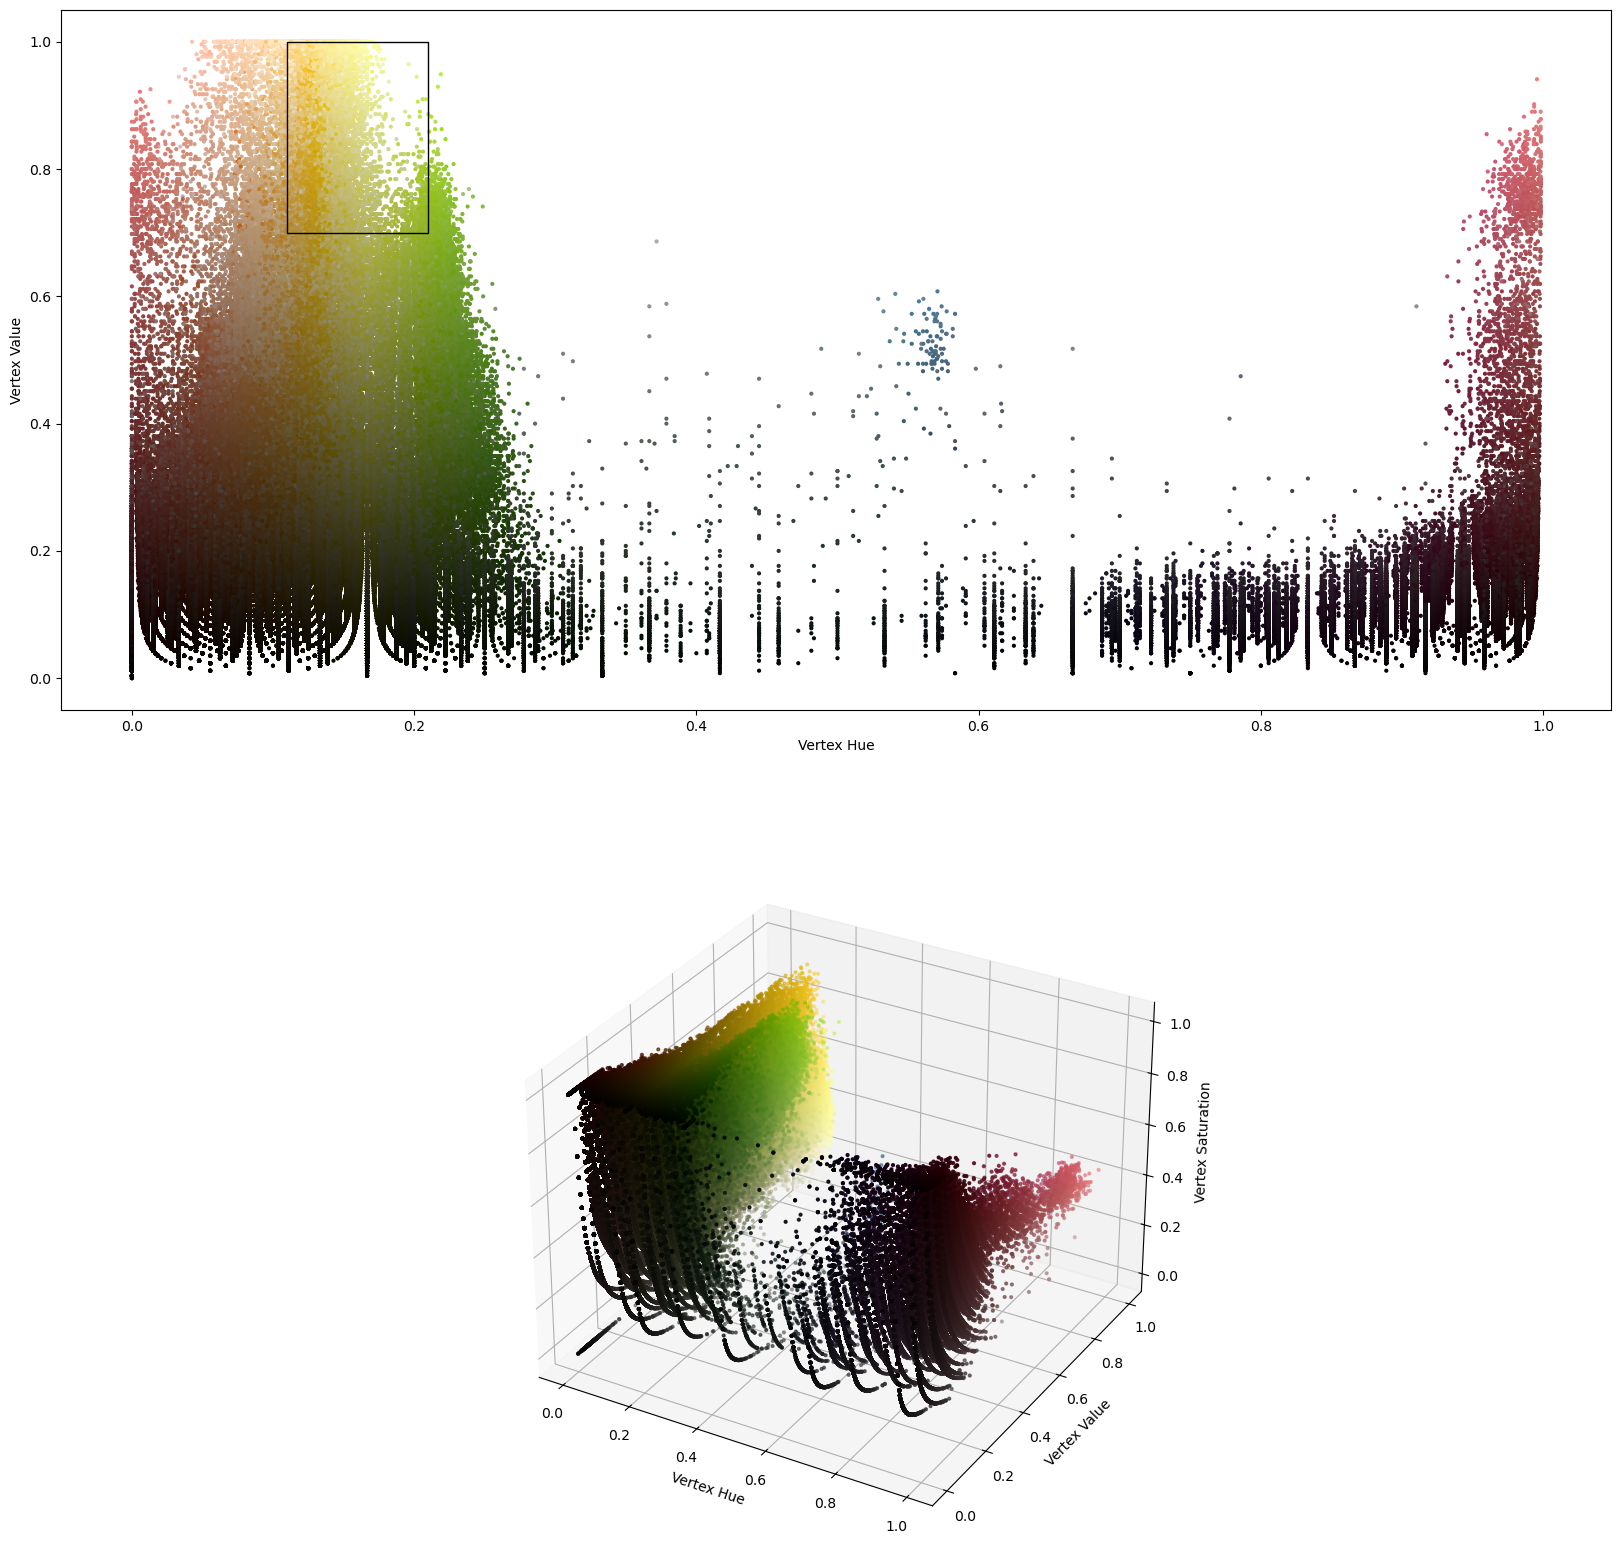

In [44]:
from cedalion.geometry.photogrammetry.processors import ColoredStickerProcessor

# nb41 default yellow range. If count is 0 on Subject16-22, look at the
# vertex-color scatter below and widen the HSV window accordingly.
STICKER_HSV = {"O": (0.11, 0.21, 0.7, 1.0)}
OPTODE_LENGTH = 22.6 * cedalion.units.mm

processor = ColoredStickerProcessor(colors=STICKER_HSV)
centers_h, normals_h, details_h = processor.process(surface_h, details=True)
print(f'Stickers detected on original: {len(centers_h)}')

details_h.plot_vertex_colors()
plt.show()

In [45]:
centers_anon, normals_anon, details_anon = processor.process(
    surface_anon, details=True
)
print(f'Stickers detected on original:   {len(centers_h)}')
print(f'Stickers detected on anonymized: {len(centers_anon)}')
print(f'Labels original:   {list(centers_h["label"].values)}')
print(f'Labels anonymized: {list(centers_anon["label"].values)}')

[[ -85.14637603  -45.3311207  -550.53511232]
 [ -54.06411602 -125.21770066 -556.68425171]
 [ -85.56239656  -45.2187465  -550.48027075]
 ...
 [-126.30903811   24.12872194 -446.61837794]
 [-251.74365272 -216.53318818 -500.27608009]
 [-127.42518785 -235.54048938 -407.91215556]]
[[ -55.00372802 -119.87129556 -557.60451328]
 [ -54.04357226 -123.86408342 -556.79642487]
 [ -18.73912569  -97.45110731 -526.52592796]
 ...
 [ -89.21370455   20.04153786 -466.36143248]
 [ -88.92333199   19.75613378 -466.48283384]
 [ -47.2857347   -13.5402963  -484.98917796]]
O (0.11, 0.21, 0.7, 1.0)
[0.4250353  1.35472219 1.7145254  0.39138499 1.29862752 0.62320719
 0.38994548 0.61920156 0.78096456 0.49167592 1.33193309 0.74436605
 1.48520167 1.26870412 0.9219634  1.02609914 0.93732249 0.66719798
 0.08219981 1.76435313 0.45591146]
3.728244425455729
surface.crs digitized
Stickers detected on original:   21
Stickers detected on anonymized: 21
Labels original:   [np.str_('O-19'), np.str_('O-07'), np.str_('O-04'), np.s

In [46]:
# Same recipe as nb41 cell 20: subtract optode length along the surface normal.
scalp_h = centers_h - OPTODE_LENGTH * normals_h
scalp_anon = centers_anon - OPTODE_LENGTH * normals_anon
print('Scalp coords computed for both meshes.')

Scalp coords computed for both meshes.


In [47]:
from scipy.spatial import KDTree

def _deviation_table(src, dst, title):
    # Labels from two independent runs are just sequential counters and will
    # not align, so we match by nearest neighbour.
    s = src.pint.to('mm').pint.dequantify().values
    d = dst.pint.to('mm').pint.dequantify().values
    tree = KDTree(d)
    dists, _ = tree.query(s)
    print(f'\n{title}  (n_orig={len(s)}, n_anon={len(d)})')
    print(f'  mean   = {dists.mean():.3f} mm')
    print(f'  median = {np.median(dists):.3f} mm')
    print(f'  max    = {dists.max():.3f} mm')
    print(f'  per-sticker (sorted desc):')
    for k in np.argsort(-dists):
        lab = str(src['label'].values[k])
        print(f'    {lab:6s}  {dists[k]:.3f} mm')

_deviation_table(centers_h, centers_anon, 'Sticker centers (orig -> anon)')
_deviation_table(scalp_h,   scalp_anon,   'Scalp coords   (orig -> anon)')


Sticker centers (orig -> anon)  (n_orig=21, n_anon=21)
  mean   = 0.000 mm
  median = 0.000 mm
  max    = 0.000 mm
  per-sticker (sorted desc):
    O-19    0.000 mm
    O-07    0.000 mm
    O-04    0.000 mm
    O-01    0.000 mm
    O-21    0.000 mm
    O-10    0.000 mm
    O-08    0.000 mm
    O-06    0.000 mm
    O-18    0.000 mm
    O-12    0.000 mm
    O-09    0.000 mm
    O-15    0.000 mm
    O-17    0.000 mm
    O-16    0.000 mm
    O-14    0.000 mm
    O-05    0.000 mm
    O-11    0.000 mm
    O-02    0.000 mm
    O-13    0.000 mm
    O-03    0.000 mm
    O-20    0.000 mm

Scalp coords   (orig -> anon)  (n_orig=21, n_anon=21)
  mean   = 0.000 mm
  median = 0.000 mm
  max    = 0.000 mm
  per-sticker (sorted desc):
    O-19    0.000 mm
    O-07    0.000 mm
    O-04    0.000 mm
    O-01    0.000 mm
    O-21    0.000 mm
    O-10    0.000 mm
    O-08    0.000 mm
    O-06    0.000 mm
    O-18    0.000 mm
    O-12    0.000 mm
    O-09    0.000 mm
    O-15    0.000 mm
    O-17    0.000 

In [48]:
pvplt = pv.Plotter(shape=(1, 2))

pvplt.subplot(0, 0)
cedalion.plots.plot_surface(pvplt, surface_h, opacity=1.0)
cedalion.plots.plot_labeled_points(pvplt, centers_h, color='r')
cedalion.plots.plot_vector_field(pvplt, centers_h, normals_h)
pvplt.add_text(
    f'S{SUBJECT_NUMBER} Original  ({len(centers_h)} stickers)',
    position='upper_left', font_size=14,
)

pvplt.subplot(0, 1)
cedalion.plots.plot_surface(pvplt, surface_anon, opacity=1.0)
cedalion.plots.plot_labeled_points(pvplt, centers_anon, color='r')
cedalion.plots.plot_vector_field(pvplt, centers_anon, normals_anon)
pvplt.add_text(
    f'S{SUBJECT_NUMBER} Anonymized  ({len(centers_anon)} stickers)',
    position='upper_left', font_size=14,
)

pvplt.link_views()
pvplt.show()

Widget(value='<iframe src="http://localhost:45595/index.html?ui=P_0x7fd9453df290_13&reconnect=auto" class="pyv…

## Notes

- **Landmarks used:** 5 given (Nz, Iz, Cz, Lpa, Rpa), acquired via the existing
  upstream cedalion picker.
- **Mask thresholds:** `MARGIN_TOP_MM=0`, `MARGIN_BOTTOM_MM=20`, `LATERAL_SCALE=0.9`
  (tunable at the top of the notebook).
- **Anonymization method:** vertex deletion (drop faces touching masked vertices,
  strip unreferenced vertices). No Taubin smoothing. No MediaPipe.
- **Contract with the exposé:** this notebook assumes NAS/LPA/RPA are given and
  uses no DL face detection. Cz and Iz are also given and used as vertical bounds;
  they aren't strictly required but make the top/bottom cuts landmark-driven
  instead of mesh-extent-driven.
- **Relationship to notebook 47:** this is the cedalion-only alternative path.
  Notebook 47 detects Nz via MediaPipe and uses a face-oval contour for the
  upper mask bound; this notebook derives everything from the 5 given landmarks.